# pr-work #2
## First name - Bohdan | Second name - Moshnenko | Group - CS-24

In [2]:
#Кастомні функції для відображення даних
import numpy as np
import pandas as pd
from pandas import DataFrame
import matplotlib.pyplot as plt


def plot_comparison_histogram(original_data, scaled_data, method_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Графік ДО
    ax1.hist(original_data, bins=50, edgecolor='black', alpha=0.7, color='gray')
    ax1.set_title(f'Before: "{original_data.name}"')
    ax1.set_xlabel('Original Value')
    ax1.set_ylabel('Count')

    # Графік ПІСЛЯ
    ax2.hist(scaled_data, bins=50, edgecolor='black', alpha=0.7, color='green')
    ax2.set_title(f'After {method_name}: "{scaled_data.name}"')
    ax2.set_xlabel('Scaled Value')

    plt.tight_layout()
    plt.show()

def plot_histogram(df, column, bins = 20, color = 'skyblue'):
    plt.figure(figsize=(10,6))
    plt.hist(df[column].dropna(), bins = bins, color = color, edgecolor = "black")
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

### Функція для дослідження, де дані потребують нормалізації найбільше

In [1]:

financial_regression: DataFrame = pd.read_csv(r"C:\Users\mbv16\Downloads\financial_regression.csv")
only_numeric_columns = financial_regression.select_dtypes(include="number").copy()
print(only_numeric_columns.head(10))
#Можна запустити, для того щоб побачити рівномірність розподілу
#for column in only_numeric_columns.columns:
#    plot_histogram(only_numeric_columns, column)
#За результатами самий нерівномірний росподіл у колонки oil volume(29) і palladium volume(41), тому будемо працювати з ними

NameError: name 'pd' is not defined

# 1. Standardization (z-Score Scaling)

In [3]:
def z_score_scaling(col: pd.Series):
    # Формула: (X - mean) / std
    return (col - col.mean()) / col.std()

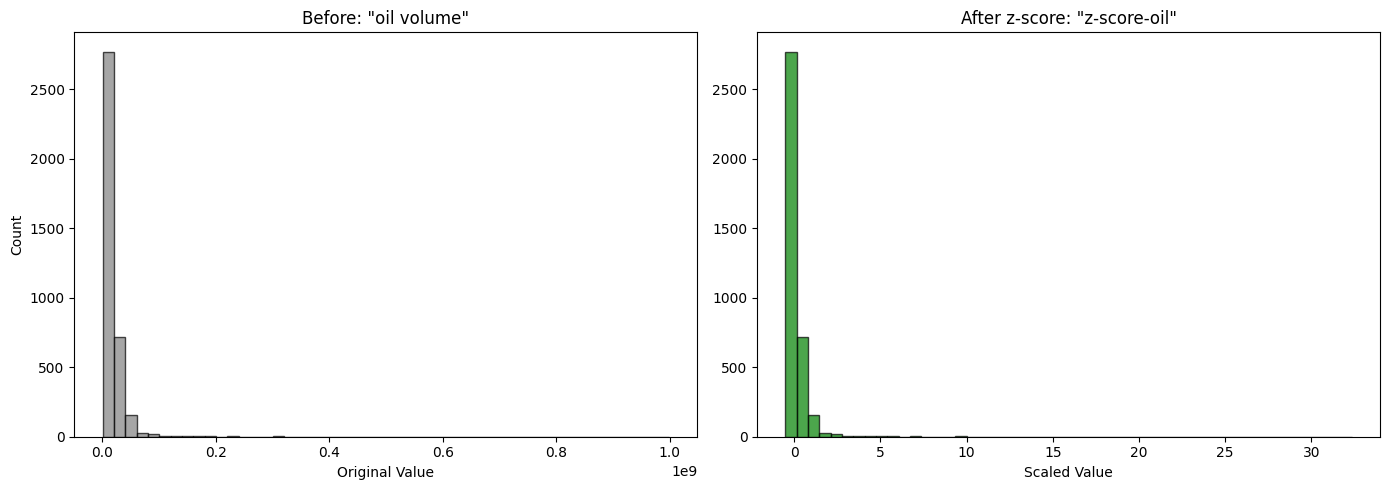

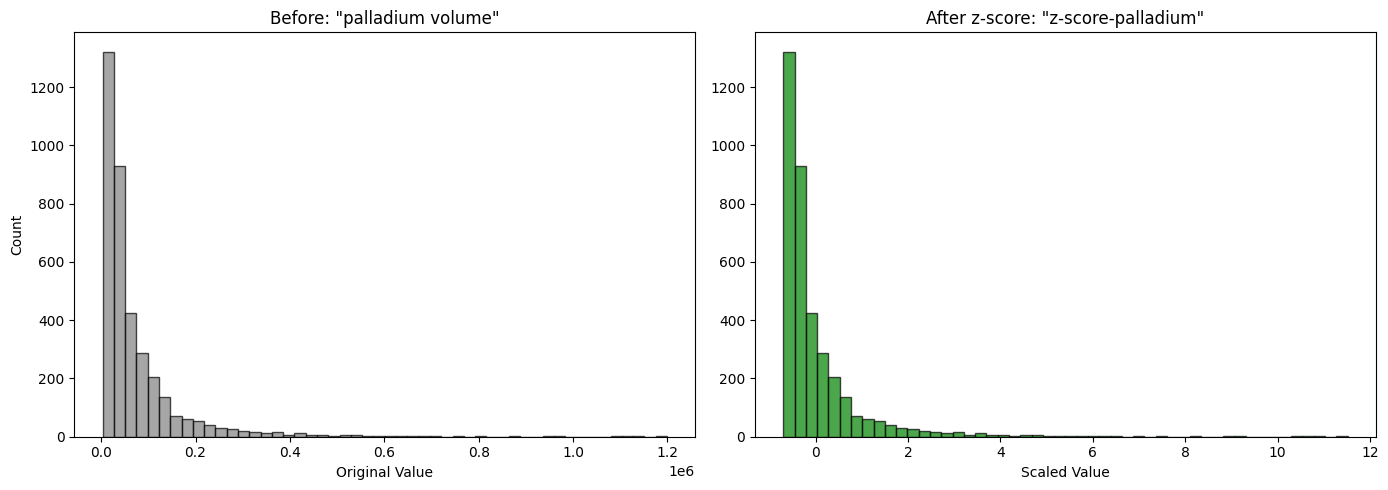

In [4]:
only_numeric_columns['z-score-oil'] = z_score_scaling(only_numeric_columns['oil volume'])
only_numeric_columns['z-score-palladium'] = z_score_scaling(only_numeric_columns['palladium volume'])
plot_comparison_histogram(only_numeric_columns['oil volume'], only_numeric_columns['z-score-oil'], 'z-score')
plot_comparison_histogram(only_numeric_columns['palladium volume'], only_numeric_columns['z-score-palladium'], 'z-score')


# 2. Min-Max Normalization

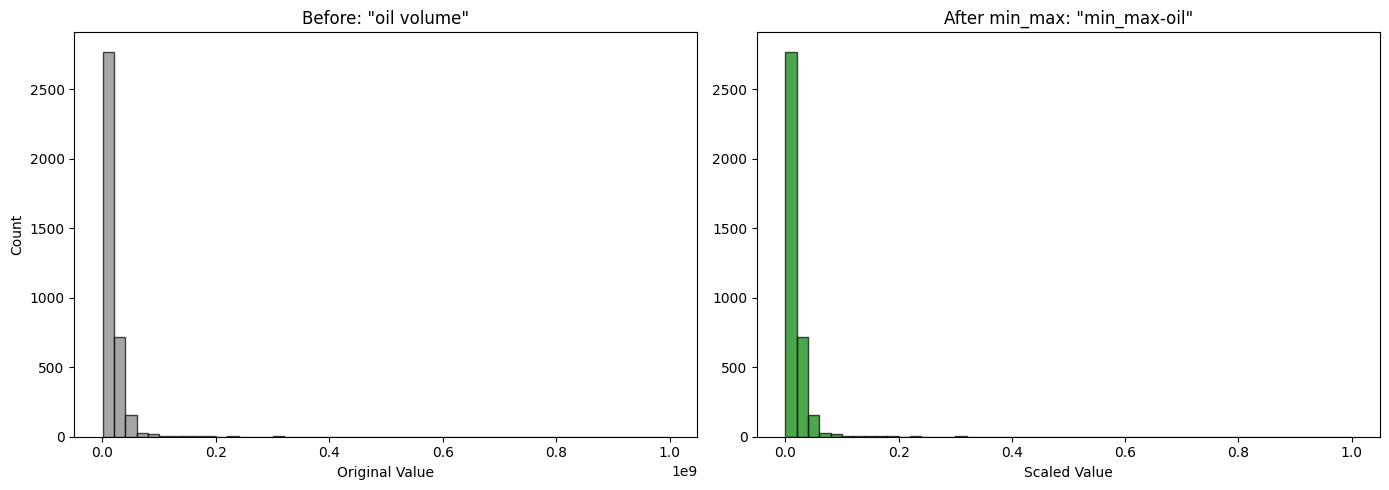

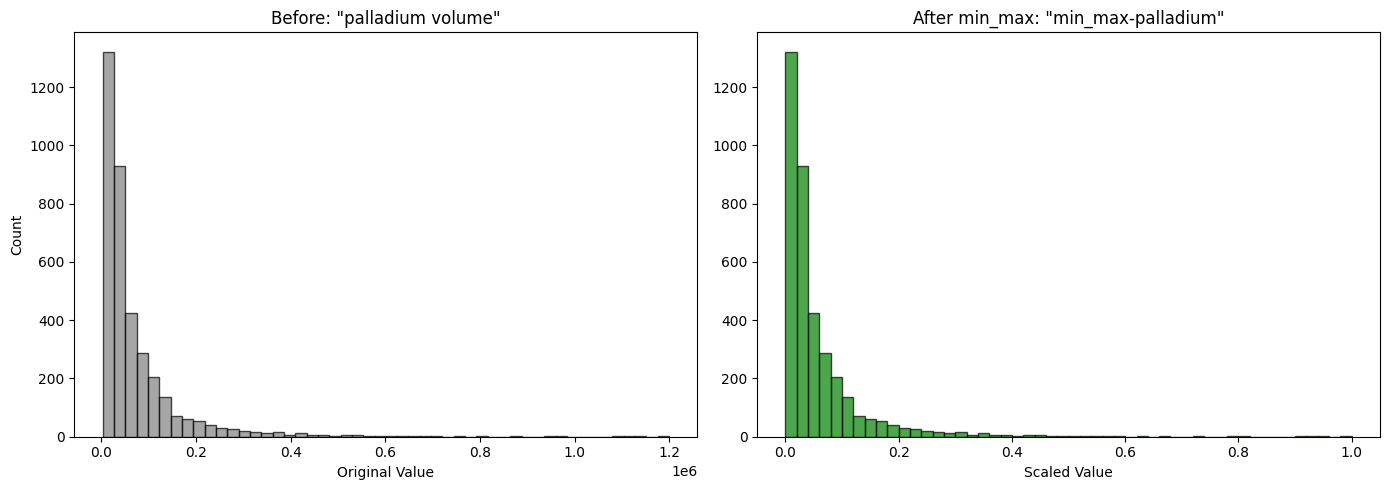

In [6]:
def min_max_normalization(col: pd.Series):
    # Формула: (X - min) / (max - min)
    return (col - col.min()) / (col.max() - col.min())
only_numeric_columns['min_max-oil'] = min_max_normalization(only_numeric_columns['oil volume'])
only_numeric_columns['min_max-palladium'] = min_max_normalization(only_numeric_columns['palladium volume'])
plot_comparison_histogram(only_numeric_columns['oil volume'], only_numeric_columns['min_max-oil'], 'min_max')
plot_comparison_histogram(only_numeric_columns['palladium volume'], only_numeric_columns['min_max-palladium'], 'min_max')

# 3. Robust Scaling

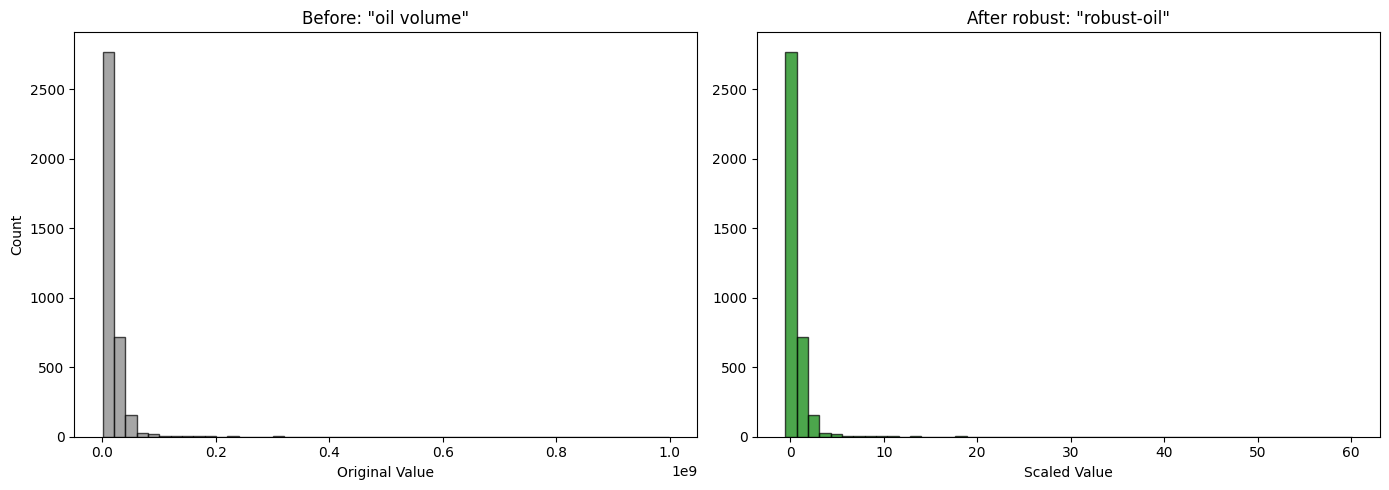

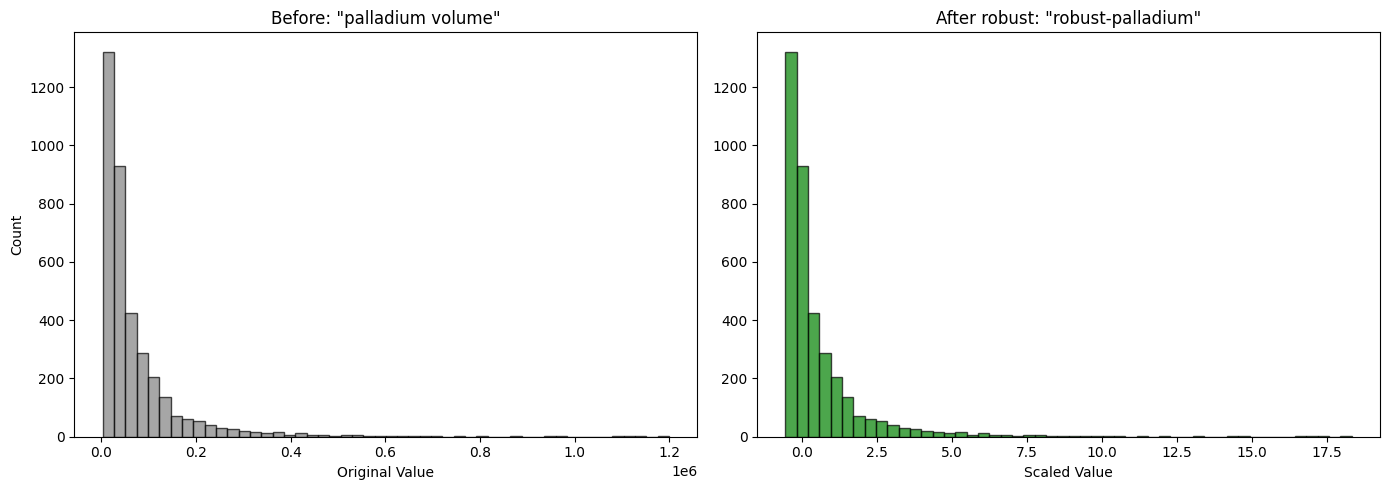

In [7]:
def robust_scaling(col: pd.Series):
    # Формула: (X - Q2) / (Q3 - Q1)
    q1 = col.quantile(0.25)
    q2 = col.median()
    q3 = col.quantile(0.75)
    return (col - q2) / (q3 - q1)
only_numeric_columns['robust-oil'] = robust_scaling(only_numeric_columns['oil volume'])
only_numeric_columns['robust-palladium'] = robust_scaling(only_numeric_columns['palladium volume'])
plot_comparison_histogram(only_numeric_columns['oil volume'], only_numeric_columns['robust-oil'], 'robust')
plot_comparison_histogram(only_numeric_columns['palladium volume'], only_numeric_columns['robust-palladium'], 'robust')

# 4. Max Absolute scaling

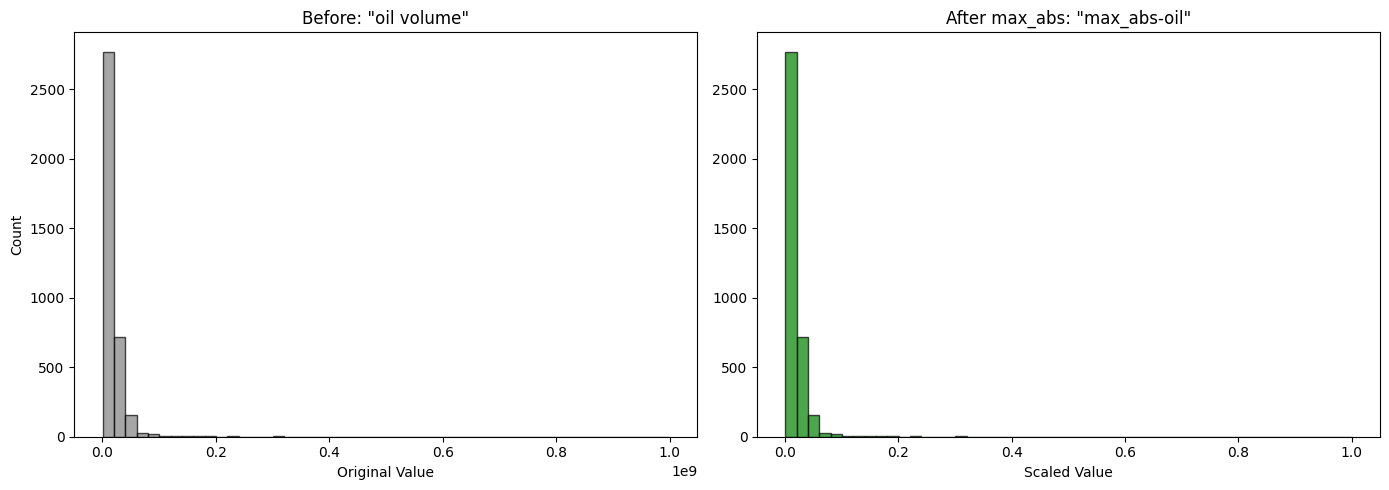

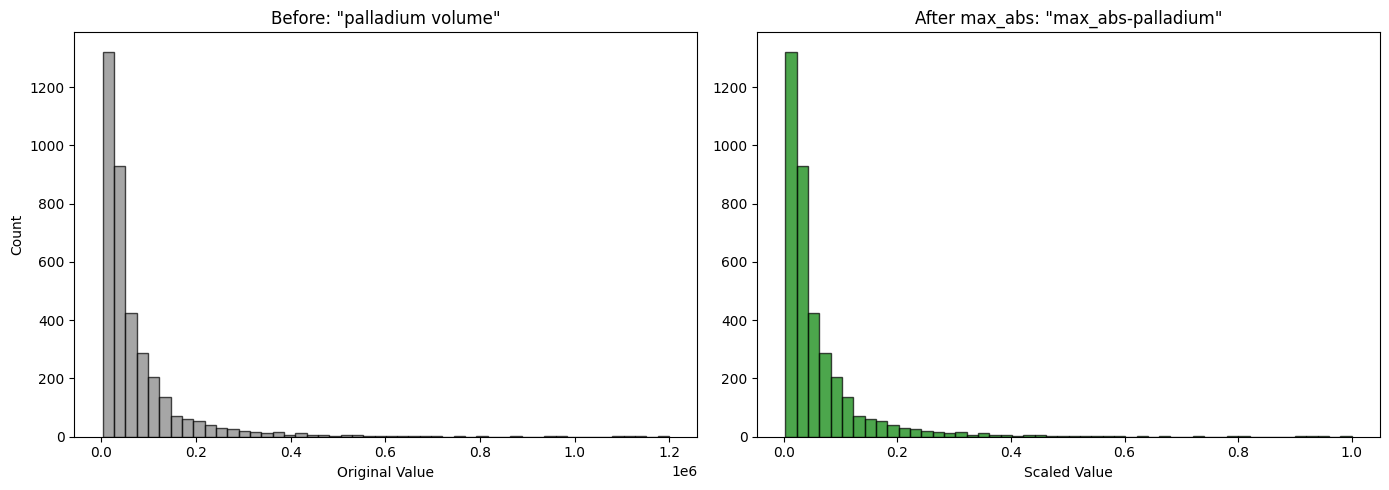

In [9]:
def max_abs_scaling(col: pd.Series):
    # Формула: X / |X|max
    return col / col.abs().max()
only_numeric_columns['max_abs-oil'] = max_abs_scaling(only_numeric_columns['oil volume'])
only_numeric_columns['max_abs-palladium'] = max_abs_scaling(only_numeric_columns['palladium volume'])
plot_comparison_histogram(only_numeric_columns['oil volume'], only_numeric_columns['max_abs-oil'], 'max_abs')
plot_comparison_histogram(only_numeric_columns['palladium volume'], only_numeric_columns['max_abs-palladium'], 'max_abs')

# 5. Mean Normalization

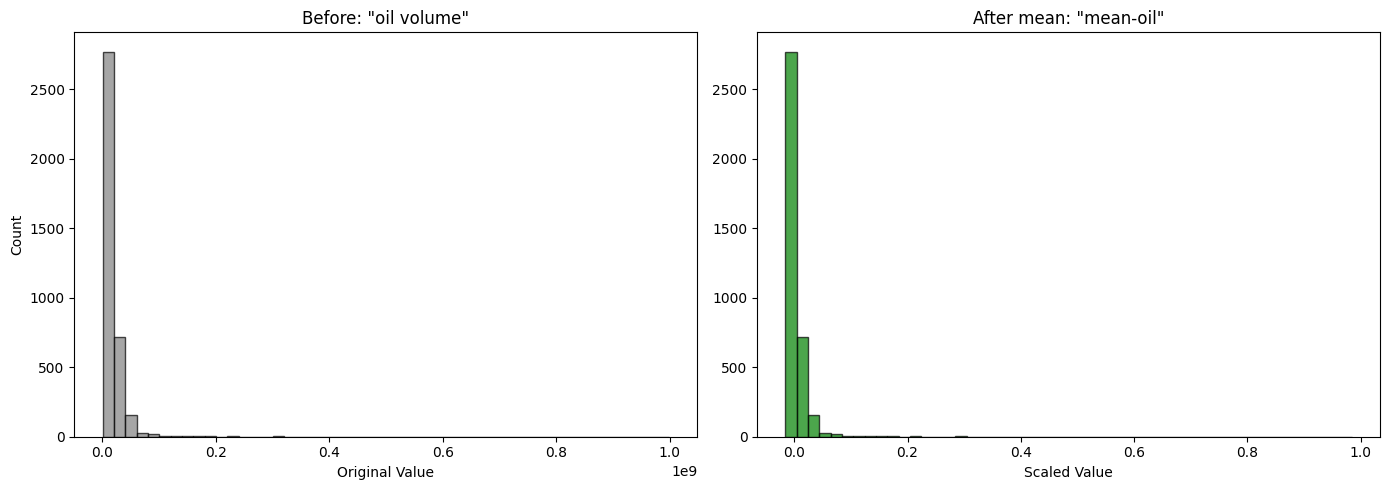

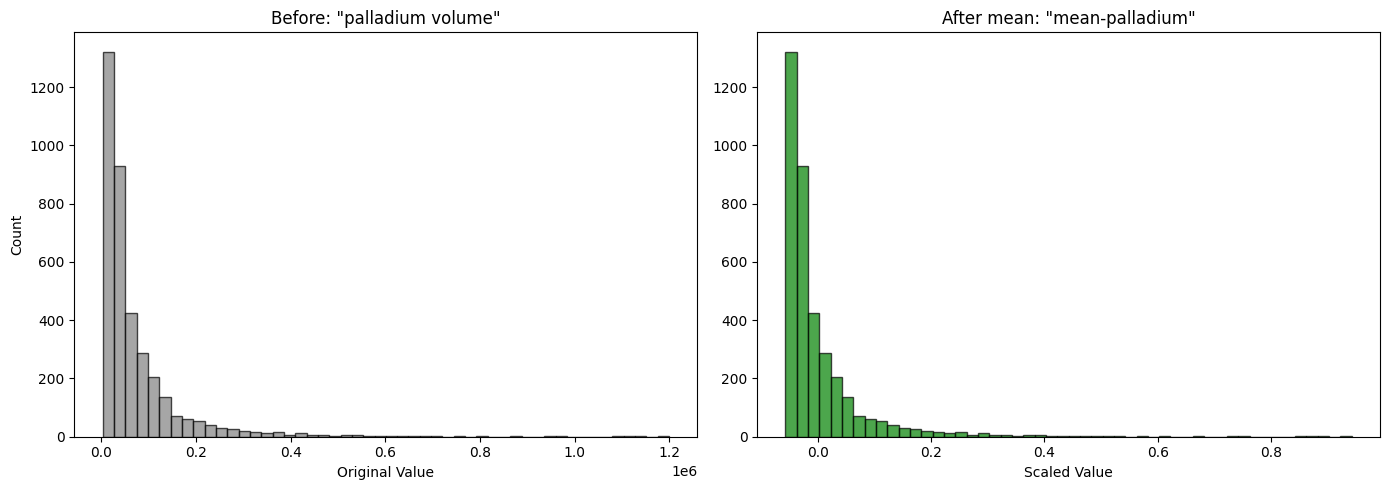

In [11]:
def mean_normalization(col: pd.Series):
    # Формула: (X - mean) / (max - min)
    return (col - col.mean()) / (col.max() - col.min())
only_numeric_columns['mean-oil'] = mean_normalization(only_numeric_columns['oil volume'])
only_numeric_columns['mean-palladium'] = mean_normalization(only_numeric_columns['palladium volume'])
plot_comparison_histogram(only_numeric_columns['oil volume'], only_numeric_columns['mean-oil'], 'mean')
plot_comparison_histogram(only_numeric_columns['palladium volume'], only_numeric_columns['mean-palladium'], 'mean')

# 6-8. Transformations (Log, Exp, Power)

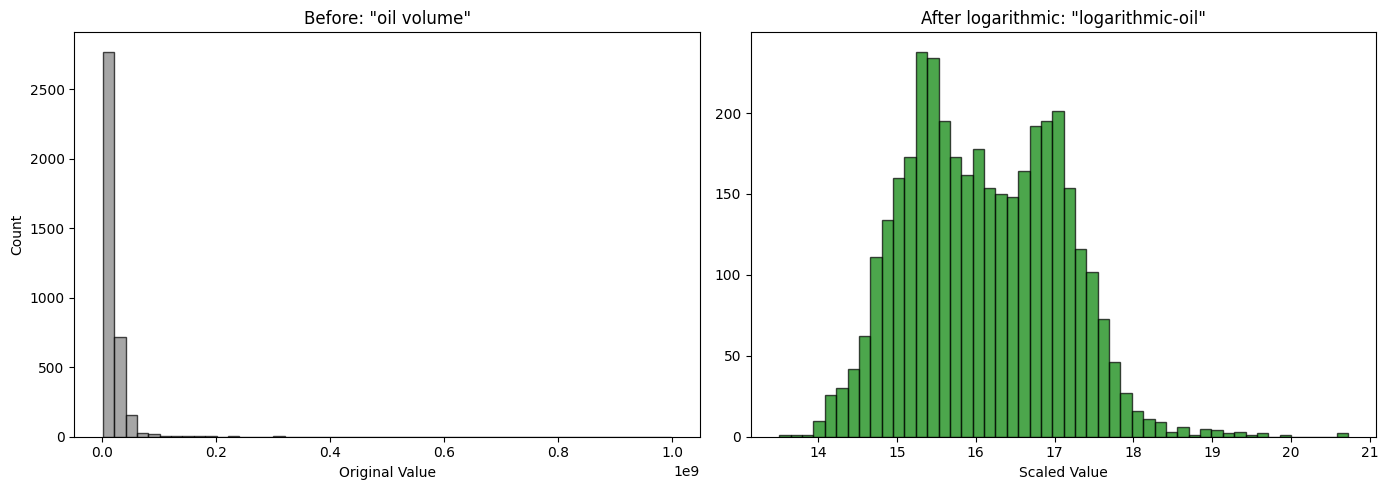

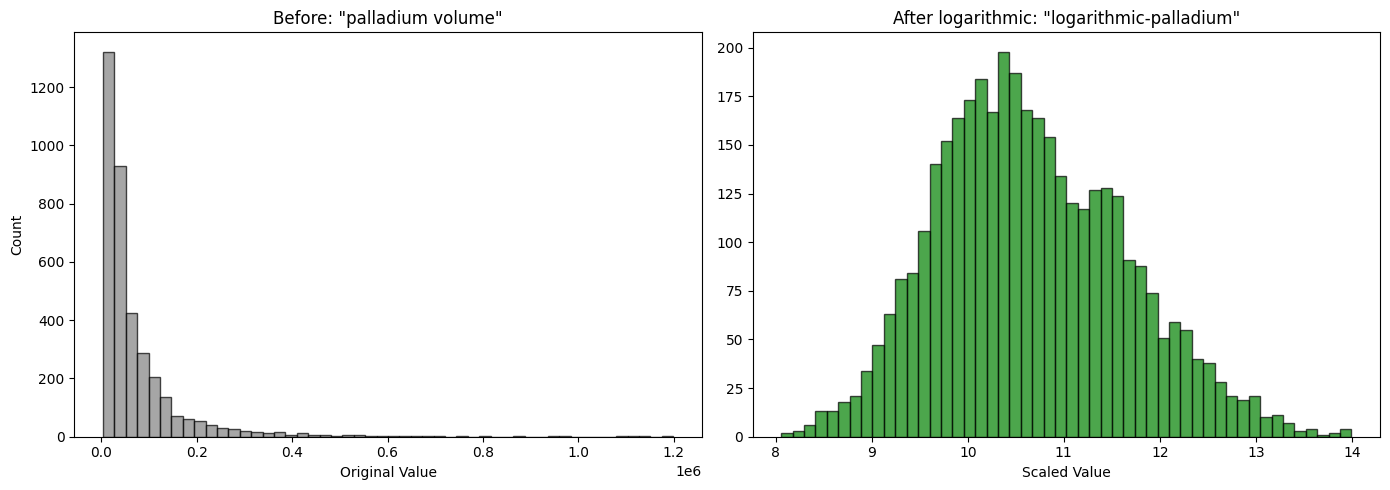

In [13]:
def logarithmic_transform(col: pd.Series):
    #для ln(X) > 0
    return np.log(col)
only_numeric_columns['logarithmic-oil'] = logarithmic_transform(only_numeric_columns['oil volume'])
only_numeric_columns['logarithmic-palladium'] = logarithmic_transform(only_numeric_columns['palladium volume'])
plot_comparison_histogram(only_numeric_columns['oil volume'], only_numeric_columns['logarithmic-oil'], 'logarithmic')
plot_comparison_histogram(only_numeric_columns['palladium volume'], only_numeric_columns['logarithmic-palladium'], 'logarithmic')

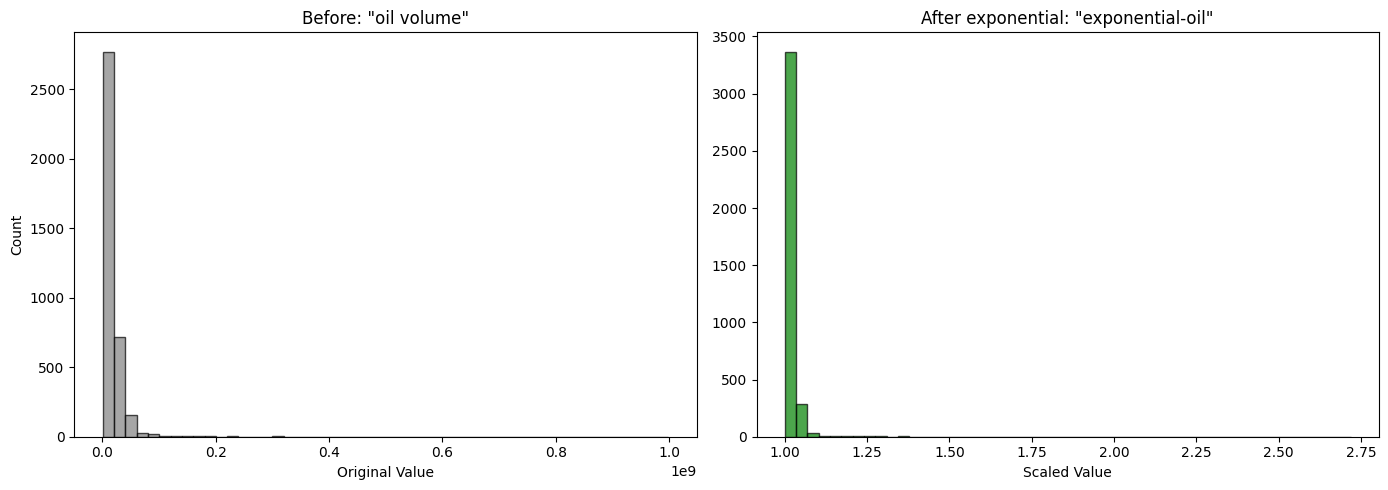

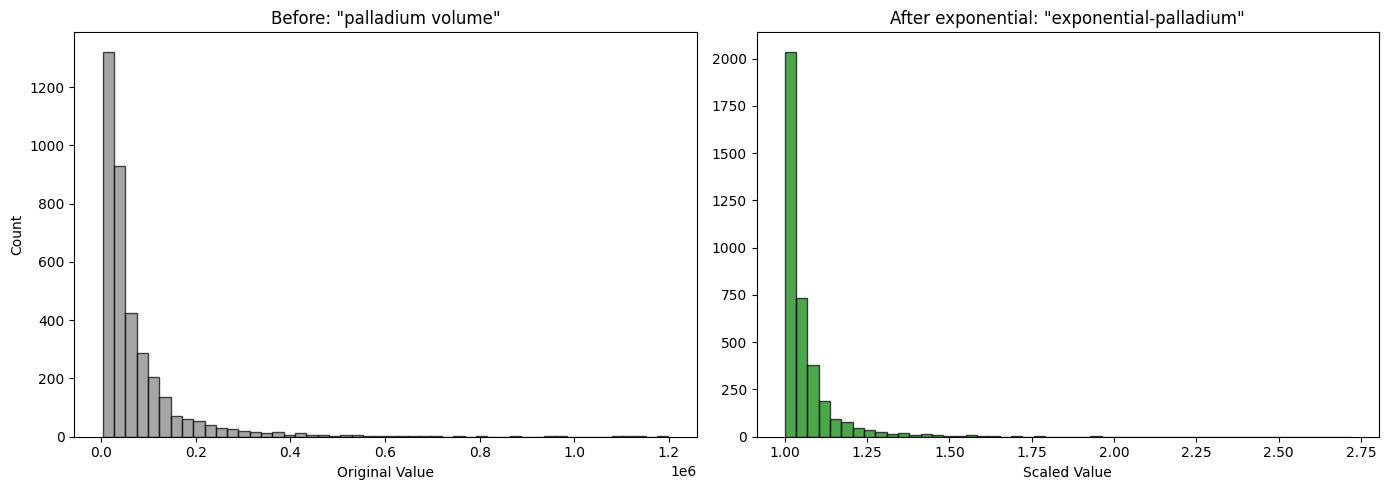

In [16]:
#Exponential transformation is not applicable to raw 'oil volume' due to overflow (values are too large for e^x). Pre-scaling is required.
def exponential_transform(col: pd.Series):
    return np.exp(col)
only_numeric_columns['exponential-oil'] = exponential_transform(only_numeric_columns['min_max-oil'])
only_numeric_columns['exponential-palladium'] = exponential_transform(only_numeric_columns['min_max-palladium'])
plot_comparison_histogram(only_numeric_columns['oil volume'], only_numeric_columns['exponential-oil'], 'exponential')
plot_comparison_histogram(only_numeric_columns['palladium volume'], only_numeric_columns['exponential-palladium'], 'exponential')

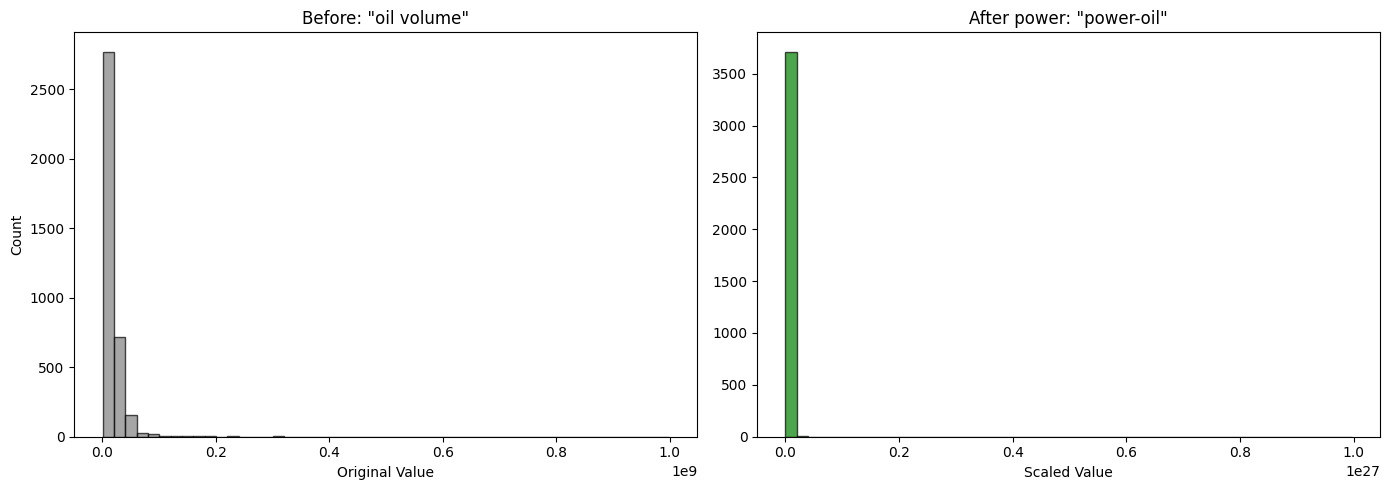

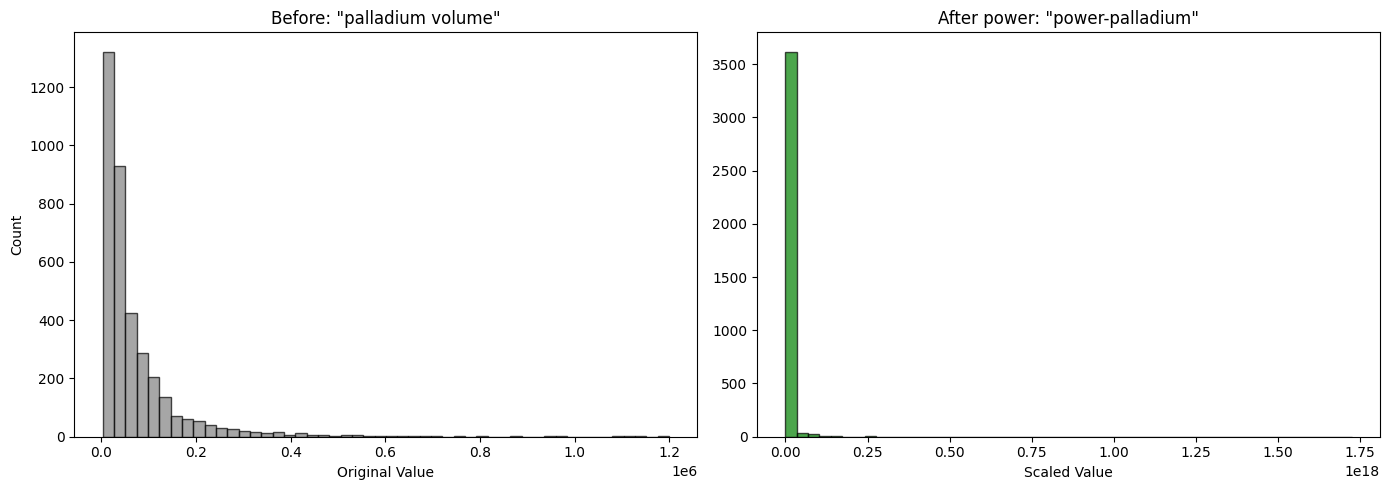

In [17]:
def power_transform(col: pd.Series, a=3):
    #X^3
    return np.power(col, a)
only_numeric_columns['power-oil'] = power_transform(only_numeric_columns['oil volume'])
only_numeric_columns['power-palladium'] = power_transform(only_numeric_columns['palladium volume'])
plot_comparison_histogram(only_numeric_columns['oil volume'], only_numeric_columns['power-oil'], 'power')
plot_comparison_histogram(only_numeric_columns['palladium volume'], only_numeric_columns['power-palladium'], 'power')

# BONUS: Vector Normalization (Row-wise)

nan


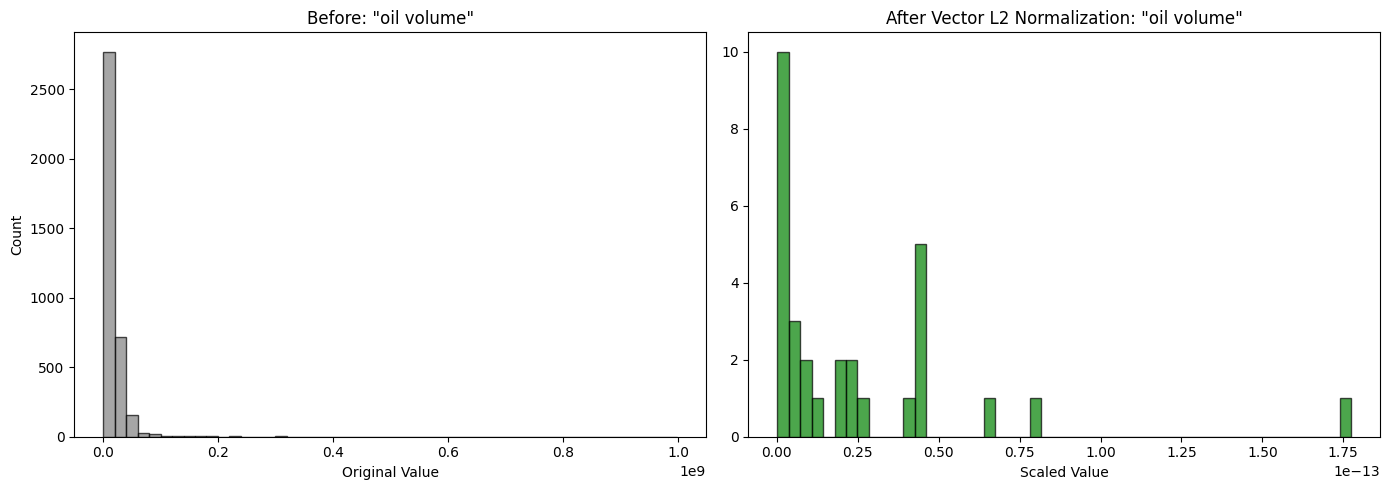

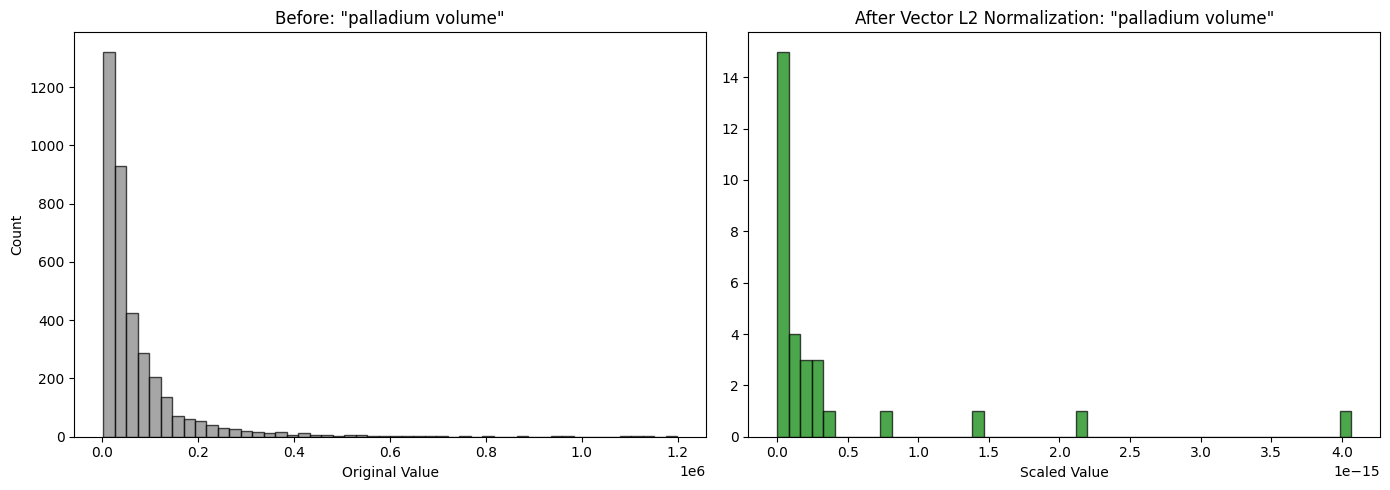

In [21]:
def vector_l2_normalization(df: pd.DataFrame):
    row_norms = np.linalg.norm(df, ord=2, axis=1, keepdims=True)
    return df / row_norms
df_l2 = vector_l2_normalization(only_numeric_columns)
print(np.linalg.norm(df_l2.iloc[0], ord=2)) # 1.0
target_col = 'oil volume'
plot_comparison_histogram(
    only_numeric_columns[target_col], 
    df_l2[target_col], 
    'Vector L2 Normalization'
)
target_col = 'palladium volume'
plot_comparison_histogram(
    only_numeric_columns[target_col], 
    df_l2[target_col], 
    'Vector L2 Normalization'
)